### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data (5 years)

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("AAPL")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-29,118.233307,119.392364,117.590474,118.486548,80819200
1,2021-03-30,116.782074,117.269072,115.769118,116.986612,85671900
2,2021-03-31,118.973564,120.307933,117.999569,118.486566,118323800
3,2021-04-01,119.801445,120.950760,119.304705,120.444286,75089100
4,2021-04-05,122.626060,122.879301,119.869651,120.648850,88651200


### Plot stock data

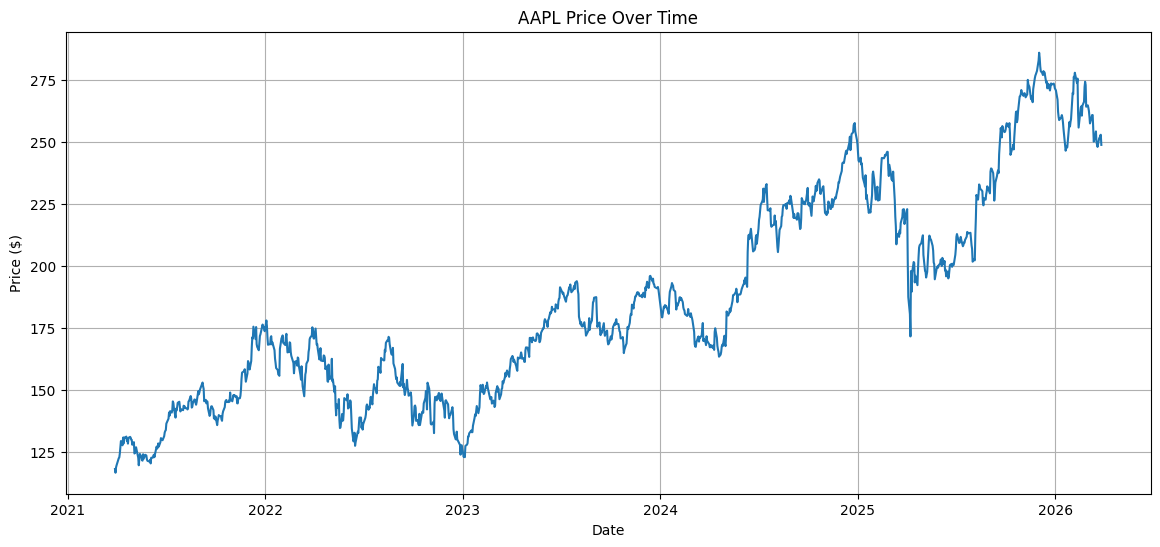

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.show()

### Plot the 9, 21, and 100 EMAs

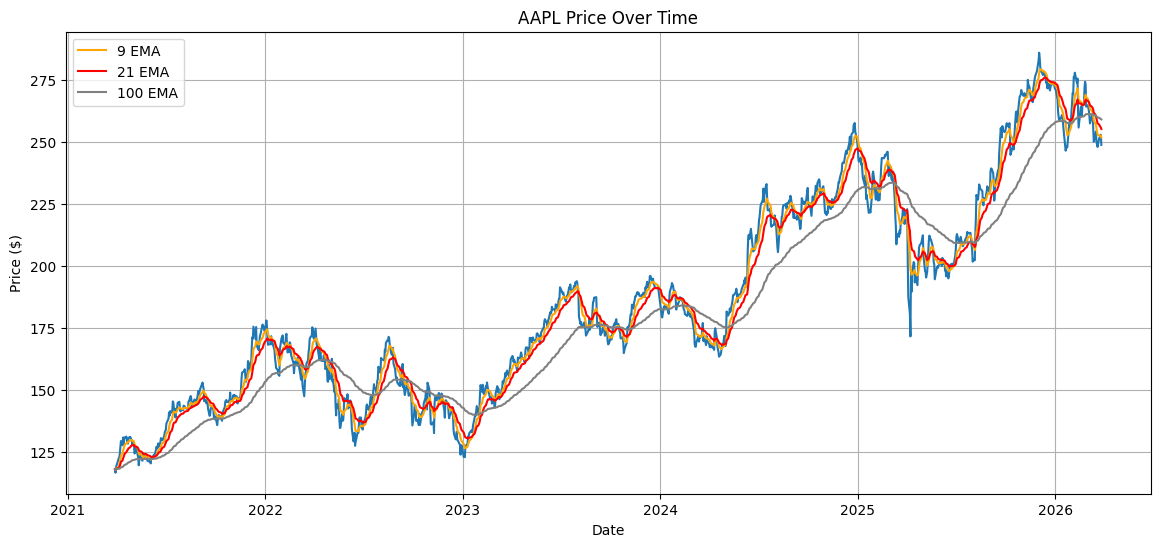

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Create 21 EMA distance, 21 EMA slope, and daily % return features

In [6]:
df["dist_ema21"] = (df["Close"] - df["ema21"]) / df["ema21"]
df["slope_ema21"] = df["ema21"].diff()
df["return"] = df["Close"].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-29,118.233307,119.392364,117.590474,118.486548,80819200,118.233307,118.233307,118.233307,0.000000,NaN,NaN
1,2021-03-30,116.782074,117.269072,115.769118,116.986612,85671900,117.943060,118.101377,118.204570,-0.011171,-0.131930,-0.012274
2,2021-03-31,118.973564,120.307933,117.999569,118.486566,118323800,118.149161,118.180666,118.219797,0.006709,0.079290,0.018766
3,2021-04-01,119.801445,120.950760,119.304705,120.444286,75089100,118.479618,118.328010,118.251117,0.012452,0.147344,0.006959
4,2021-04-05,122.626060,122.879301,119.869651,120.648850,88651200,119.308906,118.718742,118.337750,0.032912,0.390732,0.023577


In [7]:
df = df.dropna().reset_index(drop=True)
df.drop(columns=["High", "Low", "Open", "Volume"], inplace=True)
df.head()

,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782074,117.943060,118.101377,118.204570,-0.011171,-0.131930,-0.012274
1,2021-03-31,118.973564,118.149161,118.180666,118.219797,0.006709,0.079290,0.018766
2,2021-04-01,119.801445,118.479618,118.328010,118.251117,0.012452,0.147344,0.006959
3,2021-04-05,122.626060,119.308906,118.718742,118.337750,0.032912,0.390732,0.023577
4,2021-04-06,122.927979,120.032721,119.101400,118.428645,0.032129,0.382658,0.002462


### Use a 70/15/15 train/validation/test split

In [8]:
df.shape

(1255, 8)

In [9]:
train_end = int(len(df) * 0.7)
val_end = int(len(df) * 0.85)

train = df[:train_end]
val = df[train_end:val_end]
test = df[val_end:]

In [10]:
print(train.shape)
train.head()

(878, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782074,117.943060,118.101377,118.204570,-0.011171,-0.131930,-0.012274
1,2021-03-31,118.973564,118.149161,118.180666,118.219797,0.006709,0.079290,0.018766
2,2021-04-01,119.801445,118.479618,118.328010,118.251117,0.012452,0.147344,0.006959
3,2021-04-05,122.626060,119.308906,118.718742,118.337750,0.032912,0.390732,0.023577
4,2021-04-06,122.927979,120.032721,119.101400,118.428645,0.032129,0.382658,0.002462


In [11]:
print(val.shape)
val.head()

(188, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
878,2024-09-25,224.892700,223.540166,222.341680,211.404975,0.011473,0.255102,-0.004398
879,2024-09-26,226.035217,224.039176,222.677456,211.694683,0.015079,0.335776,0.005080
880,2024-09-27,226.303436,224.492028,223.007090,211.983965,0.014781,0.329635,0.001187
881,2024-09-30,231.479431,225.889509,223.777303,212.370014,0.034419,0.770213,0.022872
882,2024-10-01,224.733765,225.658360,223.864254,212.614841,0.003884,0.086951,-0.029142


In [12]:
print(test.shape)
test.head()

(189, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
1066,2025-06-27,200.469971,199.791319,200.129109,209.377172,0.001703,0.034086,0.000398
1067,2025-06-30,204.547531,200.742561,200.530784,209.281535,0.020031,0.401675,0.020340
1068,2025-07-01,207.189514,202.031952,201.136123,209.240109,0.030096,0.605339,0.012916
1069,2025-07-02,211.795486,203.984659,202.105156,209.290711,0.047947,0.969033,0.022231
1070,2025-07-03,212.902130,205.768153,203.086699,209.362224,0.048331,0.981543,0.005225


### Normalize the dataset

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
features = ["Close", "ema21", "dist_ema21", "slope_ema21", "return"]
target = "Close"

# MinMaxScaler has default param feature_range=(0,1)
features_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Training data
train_features = train[features]
train_target = train[[target]]

# Validation data
val_features = val[features]
val_target = val[[target]]

# Testing data
test_features = test[features]
test_target = test[[target]]

# Scale training data
train_features_scaled = features_scaler.fit_transform(train_features)
train_target_scaled = target_scaler.fit_transform(train_target)

window = 20

# Scale validation data
prev_window_val = train_features.tail(window)
val_features = pd.concat([prev_window_val, val_features], ignore_index=True)
val_features_scaled = features_scaler.transform(val_features)
val_target_scaled = target_scaler.transform(val_target)

# Scale testing data
# We take data from val_features (and not train_features) because data needs to stay chronological
prev_window_test = val_features.tail(window)
test_features = pd.concat([prev_window_test, test_features], ignore_index=True)
test_features_scaled = features_scaler.transform(test_features)
test_target_scaled = target_scaler.transform(test_target)

print(train_features_scaled.shape)
print(val_features_scaled.shape)
print(test_features_scaled.shape)

print(train_target_scaled.shape)
print(val_target_scaled.shape)
print(test_target_scaled.shape)

(878, 5)
(208, 5)
(209, 5)
(878, 1)
(188, 1)
(189, 1)


In [15]:
print(train_features_scaled[:3])
print(train_features_scaled[-3:])

[[0.         0.         0.44159234 0.40206603 0.31428343]
 [0.01885383 0.00075792 0.53073825 0.4631211  0.52450431]
 [0.02597626 0.00216636 0.55937105 0.48279265 0.44453959]]
[[0.94573862 0.98721163 0.6173871  0.59434717 0.37758588]
 [0.93095226 0.99035213 0.57117053 0.53516967 0.34606903]
 [0.93864481 0.99398413 0.58258746 0.55003277 0.42432755]]


In [16]:
print(test_features_scaled[:3])
print(test_features_scaled[-3:])

[[0.71029158 0.81178279 0.40686073 0.3337615  0.38152983]
 [0.71801117 0.80936265 0.43503561 0.36701704 0.42789741]
 [0.72530163 0.80789891 0.45960835 0.39593856 0.42607372]]
[[1.16864121 1.31942215 0.42892224 0.33868026 0.42378775]
 [1.17096411 1.31660477 0.43984918 0.35500468 0.40465099]
 [1.13577704 1.31048935 0.37229856 0.25527254 0.28787907]]


In [17]:
print(train_target_scaled[:3])
print(train_target_scaled[-3:])

[[0.        ]
 [0.01885383]
 [0.02597626]]
[[0.94573862]
 [0.93095226]
 [0.93864481]]


In [18]:
print(test_target_scaled[:3])
print(test_target_scaled[-3:])

[[0.71998396]
 [0.75506404]
 [0.77779356]]
[[1.16864121]
 [1.17096411]
 [1.13577704]]


### Create training sequences

In [19]:
x_train = []
y_train = []

# For each timestamp (row) x, grab the #(window) timestamps before it and add them as a singular element to x_train. Add timestamp x as an element to y_train.
for i in range(window, train_features_scaled.shape[0]):
    x_train.append(train_features_scaled[i - window : i])
    y_train.append(train_target_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(858, 20, 5)
(858,)


### Create validation sequences

In [20]:
x_val = []
y_val = []

for i in range(window, val_features_scaled.shape[0]):
    x_val.append(val_features_scaled[i - window : i])
    y_val.append(val_target_scaled[i - window, 0])

x_val = np.array(x_val)
y_val = np.array(y_val)

print(x_val.shape)
print(y_val.shape)

(188, 20, 5)
(188,)


### Create testing sequences

In [21]:
x_test = []
y_test = []

for i in range(window, test_features_scaled.shape[0]):
    x_test.append(test_features_scaled[i - window : i])
    y_test.append(test_target_scaled[i - window, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(189, 20, 5)
(189,)


### Build LSTM model

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [23]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

model.add(LSTM(units=128, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=64))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [24]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

early_stopping = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, validation_data=(x_val, y_val), shuffle=False, callbacks=[early_stopping])

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0341 - mean_absolute_error: 0.1450 - val_loss: 0.0098 - val_mean_absolute_error: 0.0752
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0223 - mean_absolute_error: 0.1197 - val_loss: 0.0078 - val_mean_absolute_error: 0.0684
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0161 - mean_absolute_error: 0.1029 - val_loss: 0.0099 - val_mean_absolute_error: 0.0770
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0120 - mean_absolute_error: 0.0907 - val_loss: 0.0105 - val_mean_absolute_error: 0.0801
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0119 - mean_absolute_error: 0.0926 - val_loss: 0.0096 - val_mean_absolute_error: 0.0763
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0126 - mean_absolute_error: 0.0954 - val_loss: 0.0075 - val_mean_absolute_error: 0.0654
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0092 - mean_absolute_error: 0.0815 - va

### Plot loss curves

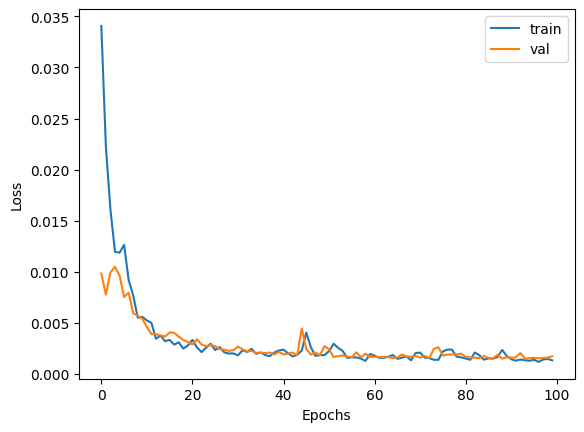

In [26]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

### Make prediction

In [27]:
y_pred = model.predict(x_test)
print(y_pred.shape)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
(189, 1)


In [28]:
print(y_test[:10])

[0.71998396 0.75506404 0.77779356 0.81741967 0.82694035 0.79606263
 0.79657723 0.80626948 0.81716238 0.80644093]


In [29]:
print(y_pred[:10])

[[0.7208969 ]
 [0.7217733 ]
 [0.75636226]
 [0.7814786 ]
 [0.8214925 ]
 [0.83130044]
 [0.80021936]
 [0.7977299 ]
 [0.8080185 ]
 [0.8207188 ]]


### Plot prediction

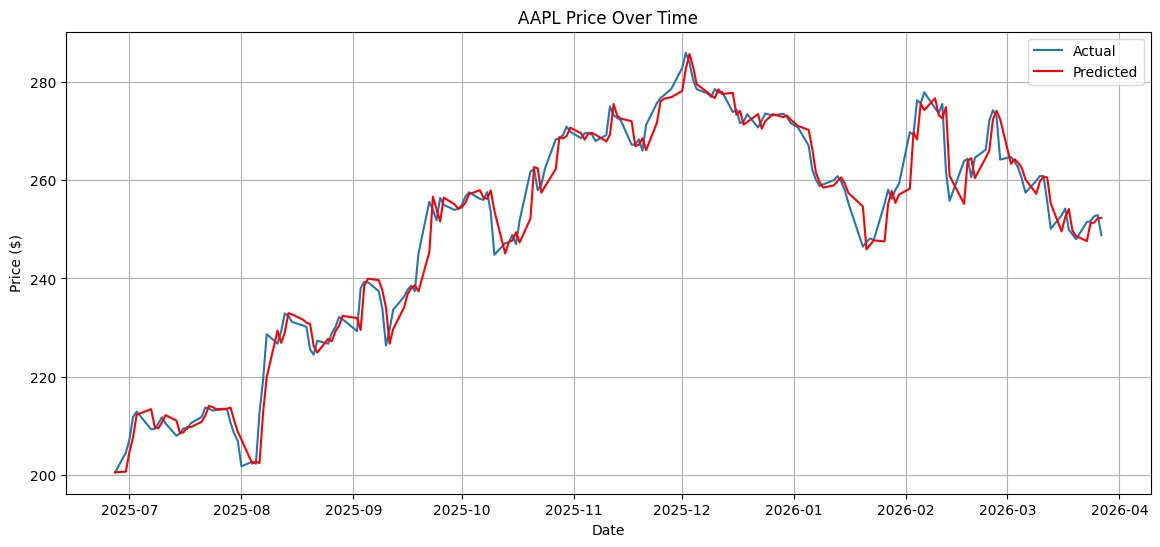

In [30]:
y_pred_prices = target_scaler.inverse_transform(y_pred).flatten()
y_test_prices = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual")
plt.plot(test["Date"], y_pred_prices, label="Predicted", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.legend()

### Model evaluation

In [31]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_prices, y_pred_prices)
print(f"MAE: ${mae:.4f}")

MAE: $2.4488


In [32]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_prices, y_pred_prices))
print(f"RMSE: ${rmse:.4f}")

RMSE: $3.4869


In [33]:
mape = np.mean(np.abs((y_test_prices - y_pred_prices) / y_test_prices)) * 100
print(f"MAPE: {mape:.4f}%")

MAPE: 0.9847%


In [34]:
actual_diff = np.diff(y_test_prices)
pred_diff = np.diff(y_pred_prices)

direction = np.mean((actual_diff > 0) == (pred_diff > 0)) * 100
print(f"Directional accuracy: {direction:.4f}%")

Directional accuracy: 55.8511%
